In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

# ---- Adobe-friendly fonts (must be set BEFORE plotting) ----
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42


df1 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-fed/speed_over_time.csv')
df1['Condition'] = 'Fed-Fed'

df2 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/fed-starved/speed_over_time.csv')
df2["Condition"] = np.where(df2["track"] == 0, "Starved (F-S)", "Fed (F-S)")

df3 = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/head-head/2/agarose-plates/socially-isolated/starved-starved/speed_over_time.csv')
df3['Condition'] = 'Starved-Starved'

df = pd.concat([df1, df2, df3], ignore_index=True)

condition_order = [
    'Fed-Fed', 'Fed (F-S)', 'Starved (F-S)', 'Starved-Starved'
]

palette = {
    'Fed-Fed': '#4C72B0',
    'Starved (F-S)': '#F3D00E',
    'Fed (F-S)': '#0B5D2A',
    'Starved-Starved': '#C44E52',
}





/var/folders/w9/3f6w3lj91rl9n89tt8fnjv5h0000gp/T/ipykernel_9583/3813632518.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


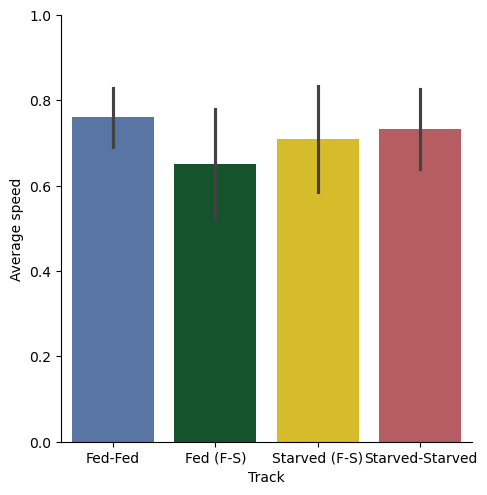

,Comparison,Test,n,stat,p,p (Holm adj.),Significant? (raw p)
0,Fed-Fed vs Fed (F-S),Mann-Whitney U,25 vs 19,361.0,0.0036,0.0143,Yes
1,Fed-Fed vs Starved-Starved,Mann-Whitney U,25 vs 19,303.0,0.1235,0.3706,No
2,Starved-Starved vs Starved (F-S),Mann-Whitney U,19 vs 19,195.0,0.6827,0.6827,No
3,Fed (F-S) vs Starved (F-S),Wilcoxon signed-rank,19 pairs,57.0,0.1336,0.3706,No


In [2]:
# speed by track, with SD error bars
from itertools import combinations
from scipy.stats import mannwhitneyu, wilcoxon

# Mean speed per larva, then average the two larvae on Fed-Fed and
# Starved-Starved plates into one value per plate, so those groups do not
# contribute two non-independent points. F-S plates already have one larva
# per Condition, so they pass through unchanged.
track_speed_summary = (
    df
    .groupby(['file', 'Condition', 'track'], as_index=False)['speed']
    .mean()
    .groupby(['file', 'Condition'], as_index=False)['speed']
    .mean()
)

# The comparisons we want. Fed (F-S) and Starved (F-S) are the two larvae on the
# SAME plate, so that one is paired; the rest are between different plates.
COMPARISONS = [
    ('Fed-Fed',         'Fed (F-S)',       'unpaired'),
    ('Fed-Fed',         'Starved-Starved', 'unpaired'),
    ('Starved-Starved', 'Starved (F-S)',   'unpaired'),
    ('Fed (F-S)',       'Starved (F-S)',   'paired'),
]


fig, ax = plt.subplots(figsize=(5, 5))

sns.barplot(
    data=track_speed_summary,
    x='Condition',
    y='speed',
    order=condition_order,
    palette=palette,
    errorbar='sd',
    ax=ax,
)

ax.set_xlabel('Track')
ax.set_ylabel('Average speed')
sns.despine(ax=ax)
plt.tight_layout()
plt.ylim(0, 1)
plt.savefig('/Users/cochral/repos/behavioural-analysis/plots/lrs_paper/fed-starved/si/speed.pdf', format='pdf')
plt.show()

mw_results = []
for condition_a, condition_b, kind in COMPARISONS:
    if kind == 'paired':
        test_name = 'Wilcoxon signed-rank'
        paired = track_speed_summary[
            track_speed_summary['Condition'].isin([condition_a, condition_b])
        ].pivot_table(index='file', columns='Condition', values='speed')

        if {condition_a, condition_b}.issubset(paired.columns):
            paired = paired.dropna(subset=[condition_a, condition_b])
        else:
            paired = paired.iloc[0:0]

        try:
            stat, p_value = wilcoxon(paired[condition_a], paired[condition_b])
        except (ValueError, KeyError):
            stat, p_value = np.nan, np.nan
        n_desc = f'{len(paired)} pairs'
    else:
        test_name = 'Mann-Whitney U'
        speeds_a = track_speed_summary.loc[
            track_speed_summary['Condition'] == condition_a, 'speed'
        ].dropna()
        speeds_b = track_speed_summary.loc[
            track_speed_summary['Condition'] == condition_b, 'speed'
        ].dropna()

        if speeds_a.empty or speeds_b.empty:
            stat, p_value = np.nan, np.nan
        else:
            stat, p_value = mannwhitneyu(speeds_a, speeds_b, alternative='two-sided')
        n_desc = f'{len(speeds_a)} vs {len(speeds_b)}'

    mw_results.append({
        'Comparison': f'{condition_a} vs {condition_b}',
        'Test': test_name,
        'n': n_desc,
        'stat': stat,
        'p': p_value,
    })

mw_table = pd.DataFrame(mw_results)
valid_p = mw_table['p'].dropna().sort_values()
holm_adjusted = pd.Series(np.nan, index=mw_table.index, dtype=float)
if not valid_p.empty:
    adjusted_sorted = (valid_p * (len(valid_p) - np.arange(len(valid_p)))).cummax().clip(upper=1)
    holm_adjusted.loc[adjusted_sorted.index] = adjusted_sorted

# Only one measure here (mean speed), so unlike the syllable notebooks there is
# nothing to FDR-correct across. Report p raw; the Holm column across these four
# planned comparisons is a conservative secondary.
mw_table['p (Holm adj.)'] = holm_adjusted
mw_table['Significant? (raw p)'] = np.where(mw_table['p'] < 0.05, 'Yes', 'No')
mw_table[['stat', 'p', 'p (Holm adj.)']] = mw_table[['stat', 'p', 'p (Holm adj.)']].round(4)
display(mw_table)

